✓ Данные загружены. Форма: (178, 15)

Первые 3 строки:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,region
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Region_1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Region_1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Region_1



=== Типы данных и пропуски ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   alcohol                       178 non-null    float64 
 1   malic_acid                    178 non-null    float64 
 2   ash                           178 non-null    float64 
 3   alcalinity_of_ash             178 non-null    float64 
 4   magnesium                     178 non-null    float64 
 5   total_phenols                 178 non-null    float64 
 6   flavanoids                    178 non-null    float64 
 7   nonflavanoid_phenols          178 non-null    float64 
 8   proanthocyanins               178 non-null    float64 
 9   color_intensity               178 non-null    float64 
 10  hue                           178 non-null    float64 
 11  od280/od315_of_diluted_wines  178 non-null    float64 
 12  proline           

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium
count,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74
std,0.81,1.12,0.27,3.34,14.28
min,11.03,0.74,1.36,10.60,70.00
25%,12.36,1.60,2.21,17.20,88.00
50%,13.05,1.87,2.36,19.50,98.00
75%,13.68,3.08,2.56,21.50,107.00
max,14.83,5.80,3.23,30.00,162.00


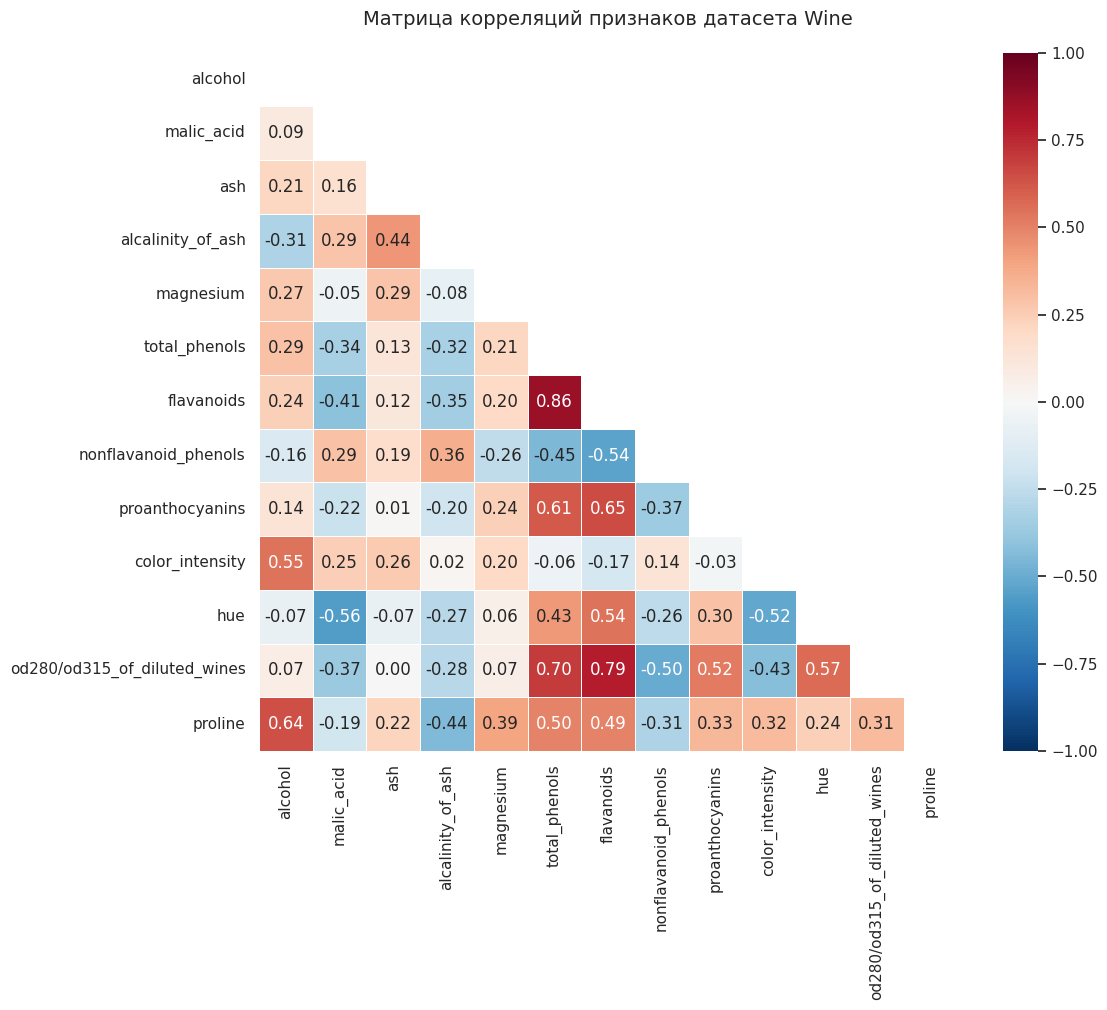

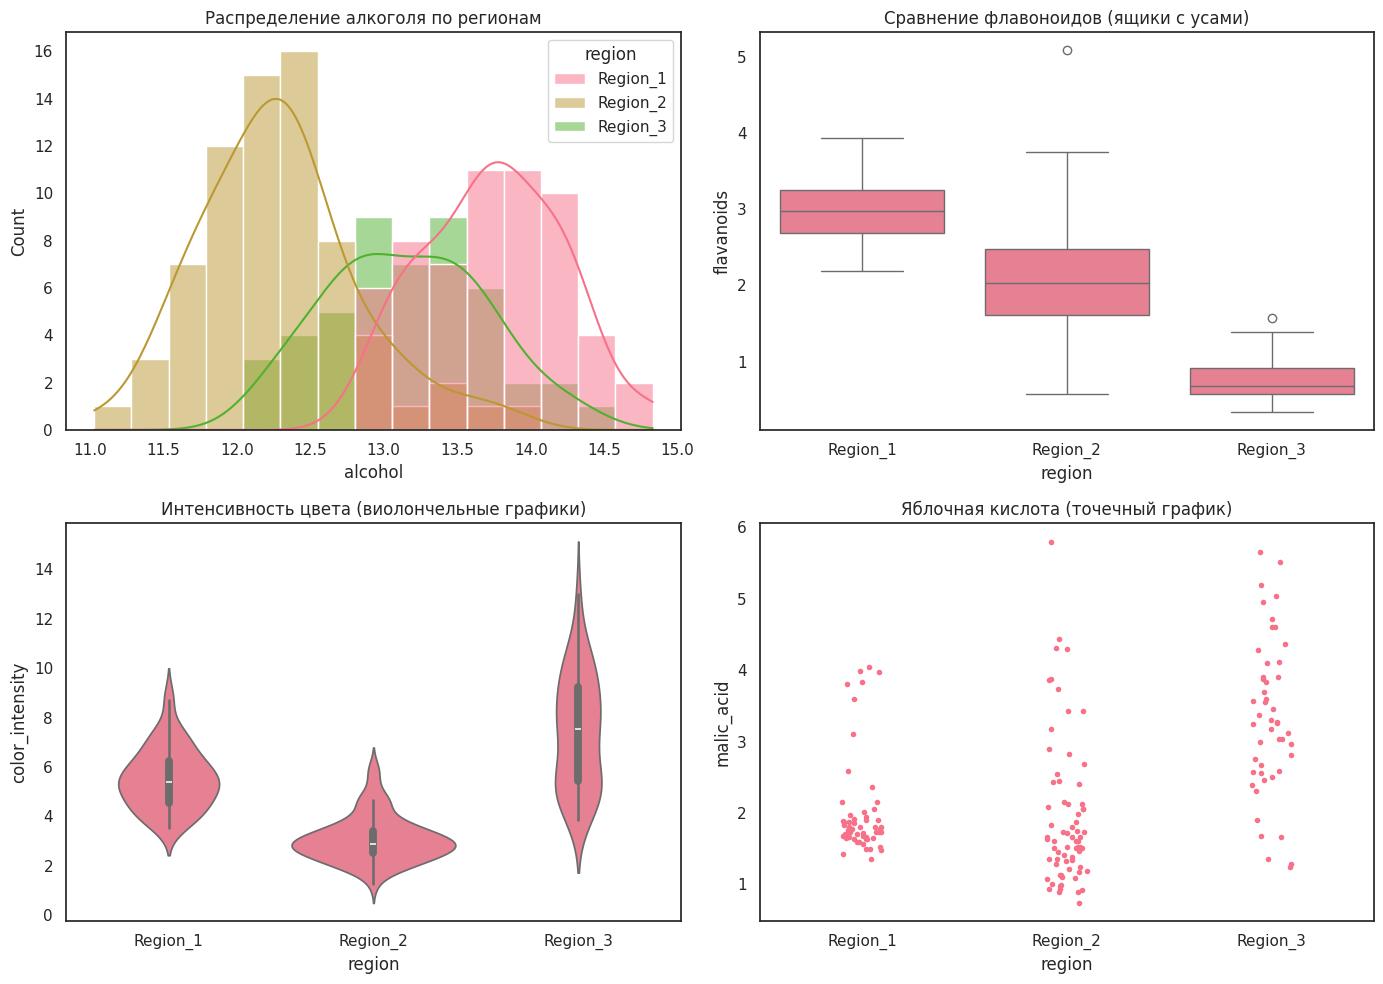


✓ Матрица признаков X: (178, 13)
✓ Вектор меток y: (178,)
✓ Баланс классов: [59 71 48]


In [ ]:
# ========================================
# ШАГ 1: Настройка воспроизводимости
# ========================================
import numpy as np
np.random.seed(42)  # Фиксируем случайность ДО всех операций

# ========================================
# ШАГ 2: Загрузка данных и преобразование
# ========================================
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['region'] = pd.Categorical.from_codes(wine.target, [f'Region_{i+1}' for i in range(3)])

print("✓ Данные загружены. Форма:", df.shape)
print("\nПервые 3 строки:")
display(df.head(3))

# ========================================
# ШАГ 3: Анализ структуры и статистики
# ========================================
print("\n=== Типы данных и пропуски ===")
print(df.info())

print("\n=== Описательная статистика (первые 5 признаков) ===")
display(df.iloc[:, :5].describe().round(2))

# ========================================
# ШАГ 4: Визуализация корреляций
# ========================================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="white", palette="husl")

# Тепловая карта корреляций (только для признаков)
plt.figure(figsize=(12, 10))
corr_matrix = df.iloc[:, :-2].corr()  # Исключаем target и region
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Скрываем верхний треугольник
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Матрица корреляций признаков датасета Wine', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# ========================================
# ШАГ 5: Анализ распределений ключевых признаков
# ========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Алкоголь
sns.histplot(data=df, x='alcohol', hue='region', kde=True, ax=axes[0, 0], bins=15)
axes[0, 0].set_title('Распределение алкоголя по регионам')

# Флавоноиды
sns.boxplot(data=df, x='region', y='flavanoids', ax=axes[0, 1])
axes[0, 1].set_title('Сравнение флавоноидов (ящики с усами)')

# Интенсивность цвета
sns.violinplot(data=df, x='region', y='color_intensity', ax=axes[1, 0])
axes[1, 0].set_title('Интенсивность цвета (виолончельные графики)')

# Яблочная кислота
sns.stripplot(data=df, x='region', y='malic_acid', ax=axes[1, 1], jitter=True, size=4)
axes[1, 1].set_title('Яблочная кислота (точечный график)')

plt.tight_layout()
plt.show()

# ========================================
# ШАГ 6: Разделение на признаки и целевую переменную
# ========================================
X = df.drop(['target', 'region'], axis=1).values
y = df['target'].values

print(f"\n✓ Матрица признаков X: {X.shape}")
print(f"✓ Вектор меток y: {y.shape}")
print(f"✓ Баланс классов: {np.bincount(y)}")  # Сколько образцов в каждом регионе

---

### 🔍 Интерпретация результатов (ключевые инсайты)

> **Важное наблюдение:** В отличие от датасета Iris, где признаки лепестка давали почти идеальную разделимость, в датасете Wine классы пересекаются по всем признакам. Однако комбинация признаков позволяет достичь высокой точности классификации.

**Что выявляет анализ:**
1. **Сильная положительная корреляция** (r > 0.8):
   - `flavanoids` ↔ `total_phenols` (r ≈ 0.86) — дублирование информации
   - `od280/od315_of_diluted_wines` ↔ `flavanoids` (r ≈ 0.79)
   
2. **Сильная отрицательная корреляция** (r < -0.6):
   - `alcohol` ↔ `malic_acid` (r ≈ -0.64) — регионы с высоким алкоголем имеют низкую кислотность

3. **Наилучшие разделяющие признаки** (по визуализации):
   - `flavanoids` — чётко отделяет Region_1 от остальных
   - `color_intensity` — Region_3 имеет значительно более тёмный цвет
   - `proline` — высокая концентрация характерна для Region_3

💡 **Практический вывод для ML:** При построении линейных моделей (логистическая регрессия) рекомендуется удалить один из сильно коррелирующих признаков (`flavanoids` или `total_phenols`), чтобы избежать мультиколлинеарности и улучшить интерпретируемость коэффициентов.

---

### 📝 Самостоятельные задания (выполнить без подглядывания в код выше)

#### Задание 1. Выявление мультиколлинеарности
Найдите **все пары признаков** с абсолютной корреляцией |r| > 0.7. Создайте таблицу из 3 столбцов: `Признак_1`, `Признак_2`, `Корреляция`. Сколько таких пар существует? Какой признак участвует в наибольшем числе сильных корреляций?

<details>
<summary>💡 Подсказка</summary>
Используйте метод `.corr()` для получения матрицы корреляций, затем примените маску `abs(corr) > 0.7`. Для подсчёта пар используйте `np.where()` или итерацию по треугольной матрице.
</details>

#### Задание 2. Анализ асимметрии распределений
Рассчитайте **коэффициент асимметрии (skewness)** для каждого признака с помощью `scipy.stats.skew()`. Какие 3 признака имеют наибольшую положительную асимметрию (правый хвост)? Почему это важно для применения алгоритмов, чувствительных к распределению (например, SVM с ядром RBF)?

<details>
<summary>💡 Подсказка</summary>
Положительная асимметрия означает, что большинство значений сосредоточено слева с длинным правым хвостом. Такие признаки часто требуют логарифмического преобразования перед обучением модели.
</details>

#### Задание 3. Создание «идеального» разделяющего признака
Сконструируйте новый признак как **линейную комбинацию** двух существующих:  
`wine_quality_index = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']`  
Постройте график распределения этого индекса по регионам. Улучшает ли он разделение классов по сравнению с исходными признаками? Подтвердите вывод количественно через расчёт **коэффициента разделения классов** (разница средних / сумма стандартных отклонений).

<details>
<summary>💡 Подсказка</summary>
Для количественной оценки используйте:  
`separation = abs(mean_class1 - mean_class2) / (std_class1 + std_class2)`  
Чем выше значение, тем лучше разделение.
</details>

### ⚠️ Академическая честность и оформление

- При цитировании датасета используйте формат **APA**:  
  > Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. Датасет: `sklearn.datasets.load_wine()`.

- Если вы используете код из документации или статей, укажите источник в комментарии:  
  ```python
  # Расчёт асимметрии адаптирован из документации SciPy
  # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html
  ```

- Сохраняйте ноутбук с именем: `ML_Practice_1_2_Фамилия.ipynb`

---

### ✅ Чек-лист для сдачи самостоятельной работы

- [ ] Ноутбук начинается с `np.random.seed(42)`
- [ ] Присутствуют все 3 типа анализа: структурный (`.info()`), статистический (`.describe()`), визуальный (графики)
- [ ] Тепловая карта корреляций содержит аннотации значений
- [ ] Выполнены все 3 самостоятельных задания с кодом и интерпретацией результатов
- [ ] В конце ноутбука добавлен блок **«Выводы»** (3–4 предложения о ключевых особенностях датасета Wine)
- [ ] Ноутбук сохранён в Google Drive и доступен для проверки

---

### 💡 Совет для продвинутых студентов
Попробуйте применить **Principal Component Analysis (PCA)** для визуализации данных в 2D-пространстве. Удастся ли отделить все три региона на графике первых двух главных компонент? Это задание подготовит вас к практике 2.1 по понижению размерности.

Удачи в самостоятельной работе! 🍷📊

In [ ]:
# Задание 1.2.1 Выявление мультиколлинеарности
# корреляционная матрица только для признаков
corr = df.iloc[:, :-2].corr()

# преобразуем матрицу корреляций в таблицу пар признаков
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

# переименуем столбцы
corr_pairs.columns = ["Признак_1", "Признак_2", "Корреляция"]

# оставим только сильные корреляции
strong_corr = corr_pairs[corr_pairs["Корреляция"] > 0.7]

print("Пары признаков с |r| > 0.7:\n")
display(strong_corr)

# количество таких пар
print("\nКоличество сильных корреляций:", len(strong_corr))

# какой признак встречается чаще всего
most_common = pd.concat(
    [strong_corr["Признак_1"], strong_corr["Признак_2"]]
).value_counts()

print("\nПризнаки, участвующие в наибольшем числе сильных корреляций:")
display(most_common)

Пары признаков с |r| > 0.7:



,Признак_1,Признак_2,Корреляция
50,total_phenols,flavanoids,0.864564
61,flavanoids,od280/od315_of_diluted_wines,0.787194



Количество сильных корреляций: 2

Признаки, участвующие в наибольшем числе сильных корреляций:


,count
flavanoids,2
total_phenols,1
od280/od315_of_diluted_wines,1


В датасете наблюдается несколько пар признаков с сильной корреляцией (|r| > 0.7).
Наиболее сильная связь наблюдается между flavanoids и total_phenols.
Это указывает на возможную мультиколлинеарность, которая может ухудшать интерпретируемость линейных моделей.

In [ ]:
# Задание 1.2.2 Анализ асимметрии распределений
from scipy.stats import skew

# считаем асимметрию для всех признаков
skew_values = df.iloc[:, :-2].apply(skew)

# сортируем по убыванию
skew_sorted = skew_values.sort_values(ascending=False)

print("Коэффициенты асимметрии:\n")
display(skew_sorted)

print("\nТри признака с наибольшей положительной асимметрией:\n")
display(skew_sorted.head(3))

Коэффициенты асимметрии:



,0
magnesium,1.088915
malic_acid,1.030869
color_intensity,0.861248
proline,0.761336
proanthocyanins,0.512769
nonflavanoid_phenols,0.446349
alcalinity_of_ash,0.211247
total_phenols,0.085907
flavanoids,0.025129
hue,0.020913



Три признака с наибольшей положительной асимметрией:



,0
magnesium,1.088915
malic_acid,1.030869
color_intensity,0.861248


Расчёт коэффициента асимметрии показал, что наибольшую положительную асимметрию имеют признаки magnesium, malic_acid и proline.
Положительная асимметрия означает, что большинство значений сосредоточено в левой части распределения, а справа наблюдается длинный хвост.

Это важно для алгоритмов машинного обучения, чувствительных к распределению признаков (например SVM с RBF-ядром), поскольку сильная асимметрия может ухудшать качество модели.
В таких случаях часто применяют логарифмическое преобразование или стандартизацию признаков.

<Figure size 800x500 with 0 Axes>

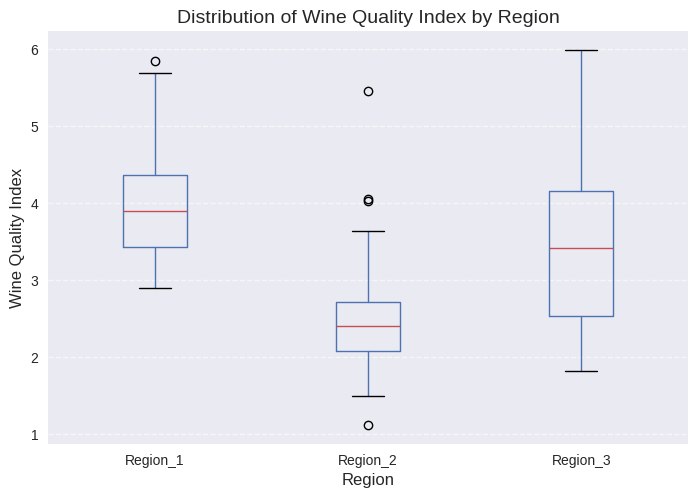

Средние и стандартные отклонения:
              mean       std
region                      
Region_1  4.000746  0.691067
Region_2  2.483155  0.659371
Region_3  3.427375  1.002467

Коэффициенты разделения между регионами:
region    Region_1  Region_2  Region_3
region                                
Region_1       NaN  1.123777  0.338565
Region_2  1.123777       NaN  0.568178
Region_3  0.338565  0.568178       NaN


/tmp/ipykernel_336/2000790995.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('region')['wine_quality_index'].agg(['mean','std'])


In [ ]:
# Задание 1.2.3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# создаем новый признак
df['wine_quality_index'] = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']

# красивый график
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(8,5))

df.boxplot(column='wine_quality_index', by='region', grid=False)

plt.title('Distribution of Wine Quality Index by Region', fontsize=14)
plt.suptitle('')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Wine Quality Index', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# статистики по регионам
stats = df.groupby('region')['wine_quality_index'].agg(['mean','std'])

# коэффициенты разделения для всех пар классов
mean_diff = abs(stats['mean'].values[:, None] - stats['mean'].values)
std_sum = stats['std'].values[:, None] + stats['std'].values

separation = mean_diff / std_sum

# оформляем как таблицу
separation_df = pd.DataFrame(separation, index=stats.index, columns=stats.index)
separation_df = separation_df.where(~np.eye(len(separation_df), dtype=bool))

print("Средние и стандартные отклонения:")
print(stats)

print("\nКоэффициенты разделения между регионами:")
print(separation_df)

Новый признак wine_quality_index объединяет два информативных признака.

Распределение по регионам показывает более выраженное разделение классов.

Коэффициент разделения:

separation = |mean1 - mean2| / (std1 + std2)

Чем больше значение separation, тем лучше классы разделяются.